## 1. Data Loading & Cleaning

In [1]:
#imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

#look at data
sales_data = pd.read_csv('data/supermarket_sales.csv')
sales_data = sales_data.dropna()
sales_data.shape[0]
sales_data['Order Date'] = pd.to_datetime(sales_data['Order Date'], format='%d/%m/%Y')
sales_data['Ship Date'] = pd.to_datetime(sales_data['Ship Date'], format='%d/%m/%Y')

In [2]:
sales_data

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9795,9796,CA-2017-125920,2017-05-21,2017-05-28,Standard Class,SH-19975,Sally Hughsby,Corporate,United States,Chicago,Illinois,60610.0,Central,OFF-BI-10003429,Office Supplies,Binders,"Cardinal HOLDit! Binder Insert Strips,Extra St...",3.7980
9796,9797,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,OFF-AR-10001374,Office Supplies,Art,"BIC Brite Liner Highlighters, Chisel Tip",10.3680
9797,9798,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10004977,Technology,Phones,GE 30524EE4,235.1880
9798,9799,CA-2016-128608,2016-01-12,2016-01-17,Standard Class,CS-12490,Cindy Schnelling,Corporate,United States,Toledo,Ohio,43615.0,East,TEC-PH-10000912,Technology,Phones,Anker 24W Portable Micro USB Car Charger,26.3760


### 1. Sales by region

In [3]:
regional_sales = sales_data.groupby(sales_data['Region'])['Sales'].sum()
regional_sales = regional_sales.reset_index()
regional_sales.columns = ['Region', 'Total Sales']
regional_sales

,Region,Total Sales
0,Central,492646.9132
1,East,660589.3560
2,South,389151.4590
3,West,710219.6845


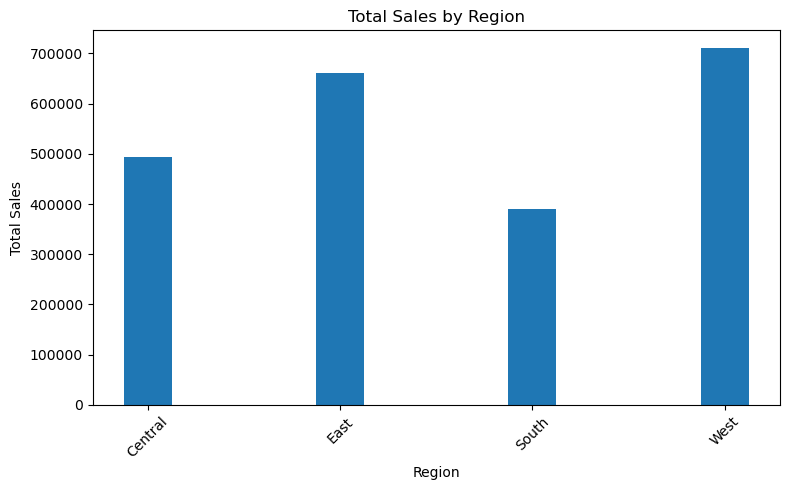

In [4]:
plt.figure(figsize=(8,5))
plt.bar(regional_sales['Region'],regional_sales['Total Sales'], width=0.25)
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.title('Total Sales by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Here we can see that the sales are highest in the West, followed by East, Central and South respectively.

## Regional Sales over time

In [5]:
regions = ['Central', 'East', 'South', 'West']
regional_sales = {}

for r in regions:
    regional_sales[r] =  sales_data[sales_data['Region'] == r].groupby([sales_data['Order Date'].dt.year.rename('Year')])['Sales'].sum().reset_index()

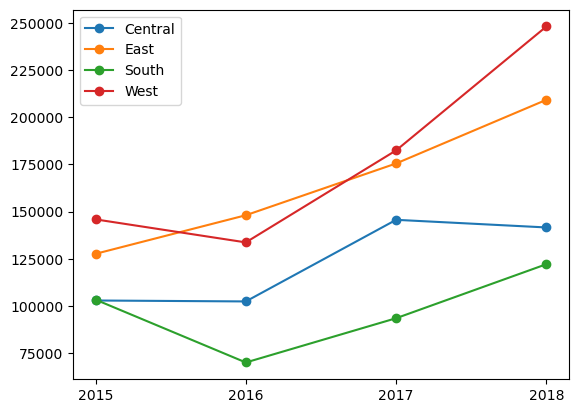

In [6]:
for r in regions:
    plt.plot(regional_sales[r]['Year'], regional_sales[r]['Sales'], label=r, marker = 'o')
plt.legend()
plt.xticks(regional_sales['Central']['Year'])
plt.show()

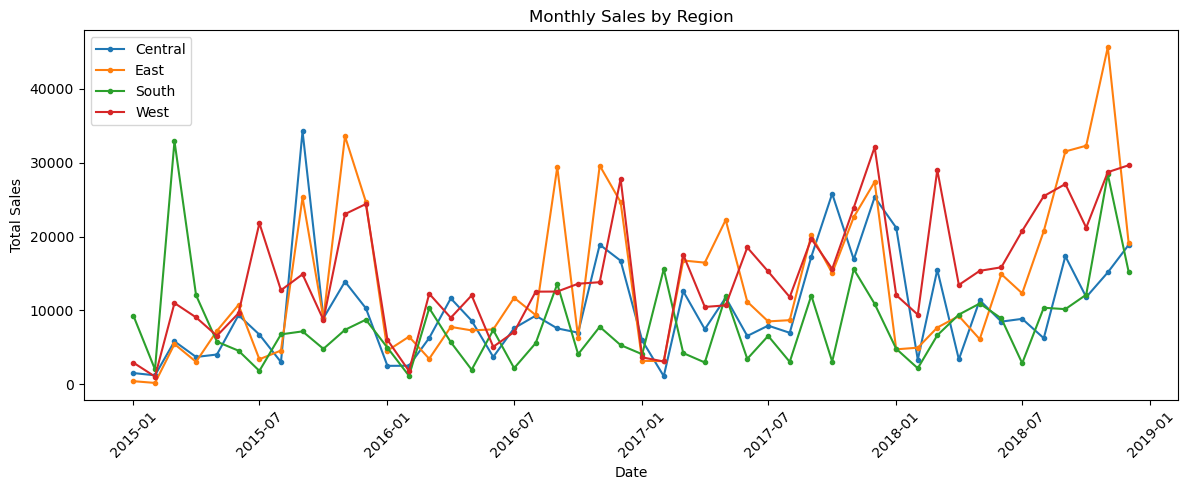

In [7]:
# checking monthly performance per region
regional_monthly_sales = {}

for r in regions:
    regional_monthly_sales[r] = sales_data[sales_data['Region'] == r].groupby(
        [sales_data['Order Date'].dt.year.rename('Year'),
         sales_data['Order Date'].dt.month.rename('Month')]
    )['Sales'].sum().reset_index()

    regional_monthly_sales[r]['Date'] = pd.to_datetime(
        regional_monthly_sales[r]['Year'].astype(str) + '-' +
        regional_monthly_sales[r]['Month'].astype(str)
    )
    regional_monthly_sales[r] = regional_monthly_sales[r].sort_values('Date')

plt.figure(figsize=(12, 5))
for r in regions:
    plt.plot(regional_monthly_sales[r]['Date'], regional_monthly_sales[r]['Sales'],
             label=r, marker='o', markersize=3)
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.title('Monthly Sales by Region')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

All four regions show the same seasonal pattern - spikes around November/December - but West and East consistently pull ahead of Central and South, especially in the later years.

### 2. Sales by Category and Sub-category

In [8]:
# check categories
print(f"The categories are {set(sales_data['Category'])}.")

The categories are {'Furniture', 'Office Supplies', 'Technology'}.


In [9]:
category_sales = sales_data.groupby(sales_data['Category'])['Sales'].sum().reset_index()
category_sales.columns = ['Category', 'Total Sales']
category_sales

,Category,Total Sales
0,Furniture,723538.4757
1,Office Supplies,703212.8240
2,Technology,825856.1130


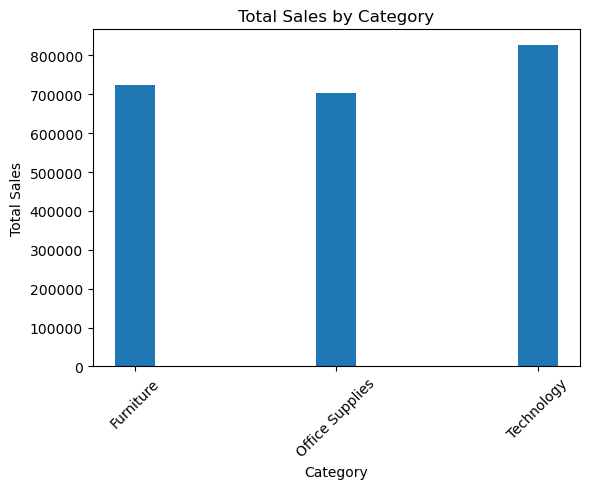

In [10]:
plt.figure(figsize=(6,5))
plt.bar(category_sales['Category'],category_sales['Total Sales'], width=0.2)
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.title('Total Sales by Category')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Here we can see that most products are sold within the technology category followed by Furniture and Office Supplies respectively.

#### Sub-Category breakdown

In [11]:
subcategory_sales = sales_data.groupby(sales_data['Sub-Category'])['Sales'].sum()
subcategory_sales = subcategory_sales.reset_index()
subcategory_sales.columns = ['Sub-Category', 'Total Sales']
subcategory_sales = subcategory_sales.sort_values('Total Sales', ascending=True)
subcategory_sales

,Sub-Category,Total Sales
8,Fasteners,3001.9600
10,Labels,12347.7260
7,Envelopes,16126.0060
2,Art,26697.3700
15,Supplies,46420.3080
12,Paper,76736.1040
9,Furnishings,89212.0180
1,Appliances,104075.4630
4,Bookcases,109408.2987
6,Copiers,146248.0940


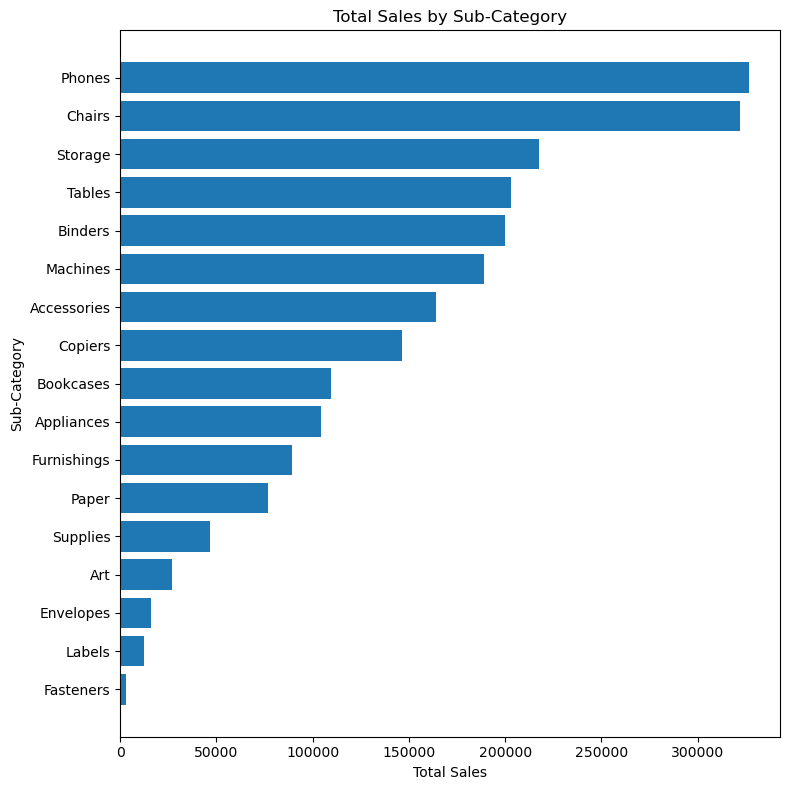

In [12]:
plt.figure(figsize=(8, 8))
plt.barh(subcategory_sales['Sub-Category'], subcategory_sales['Total Sales'])
plt.xlabel('Total Sales')
plt.ylabel('Sub-Category')
plt.title('Total Sales by Sub-Category')
plt.tight_layout()
plt.show()

Phones and Chairs are the top-selling sub-categories, while Fasteners and Labels sell the least - a much bigger spread than the top-level Category view shows on its own.

### 3. Top Customers

In [13]:
top_customers = sales_data.groupby('Customer Name')['Sales'].sum()
top_customers = top_customers.reset_index()
top_customers.columns = ['Customer Name', 'Total Sales']
top_customers = top_customers.sort_values('Total Sales', ascending=False).head(10)
top_customers

,Customer Name,Total Sales
686,Sean Miller,25043.050
730,Tamara Chand,19052.218
622,Raymond Buch,15117.339
757,Tom Ashbrook,14595.620
6,Adrian Barton,14473.571
441,Ken Lonsdale,14175.229
671,Sanjit Chand,14142.334
334,Hunter Lopez,12873.298
672,Sanjit Engle,12209.438
156,Christopher Conant,12129.072


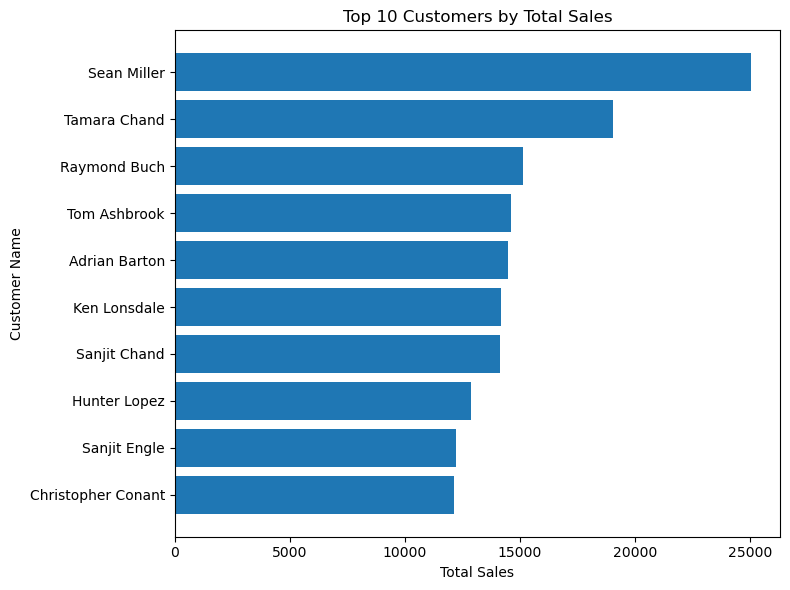

In [14]:
plt.figure(figsize=(8, 6))
plt.barh(top_customers['Customer Name'][::-1], top_customers['Total Sales'][::-1])
plt.xlabel('Total Sales')
plt.ylabel('Customer Name')
plt.title('Top 10 Customers by Total Sales')
plt.tight_layout()
plt.show()

In [15]:
# how much of total revenue do the top 10 customers represent?
top10_share = top_customers['Total Sales'].sum() / sales_data['Sales'].sum() * 100
print(f"The top 10 customers account for {top10_share:.2f}% of total sales.")

The top 10 customers account for 6.83% of total sales.


Revenue isn't heavily concentrated in a handful of customers - the top 10 make up only a small slice of total sales, meaning growth here relies on broad customer volume rather than a few big accounts (worth confirming against the printed % above).

## Next Steps

As a next step, I look into seasonality, growth by region/category, and shipping delays in `trend_timing.ipynb`, then a simple sales forecast in `forecasting.ipynb`.